In [102]:
%pip install numpy
%pip install matplotlib
%pip install imageio


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [103]:
from __future__ import annotations
from helpers.env import SlipperyGridWorld, ACTIONS
from helpers.viz import evaluate, plot_policy, plot_value_heatmap, run_to_gif
import numpy as np
import matplotlib.pyplot as plt

In [104]:
# Available actions
# Action mapping: 0=Up, 1=Right, 2=Down, 3=Left
print(ACTIONS)

(0, 1, 2, 3)


In [105]:
# =============================CONFIGURATION BLOCK============================= #
# |                   Change the parameters and see what happens              | #
# =============================CONFIGURATION BLOCK============================= #

# Example parameters set up for environment
num_rows = 5
num_cols = 7
start_state = (0, 0)
goal_state = (4, 6)
slip_prob = 0.2
random_seed = 987
step_reward = -1
goal_reward = 10

max_steps_in_env = 50 # affects sampled trajectories in Q-learning via episode truncation

# Q-learning parameters
num_episodes = 5000
epsilon = 1
min_epsilon = 0.05
decay = 0.999
alpha = 0.2
gamma = 0.99

In [106]:
import random
def epsilon_greedy(epsilon, state, Q):
    if random.random() < epsilon:
        return np.random.choice(ACTIONS)
    q = Q[state]
    return np.random.choice(np.flatnonzero(q == q.max()))

In [107]:
# Note that states have both (row, column) and row*num_cols + column representations
# i.e., tuple(int, int) or int, see functions docstrings for details
env = SlipperyGridWorld(rows=num_rows, cols=num_cols, start=start_state, goal=goal_state,
                        step_reward=step_reward, goal_reward=goal_reward,
                        slip_prob=slip_prob, max_steps=max_steps_in_env, seed=random_seed)

num_states = num_rows * num_cols # number of unique states
Q = np.zeros([num_states, len(ACTIONS)])
random.seed(0)
np.random.seed(0)
for _ in range(num_episodes):
    done = False
    state = env.reset()
    while not done:
        action = epsilon_greedy(epsilon, state, Q)
        next_state, reward, done, _ = env.step(action)
        # bootstrap unless next_state is truly terminal.
        # if the episode stops only because max_steps was reached, we still bootstrap
        Q[state, action] = Q[state, action] + alpha*(reward + gamma*np.max(Q[next_state])*(1-env.is_terminal_state(next_state)) - Q[state, action])
        state = next_state
    epsilon = np.max([min_epsilon, epsilon*decay])

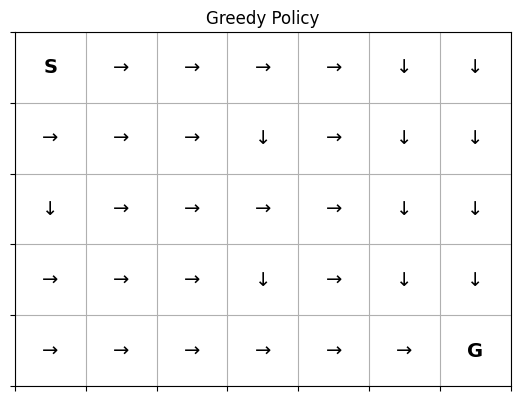

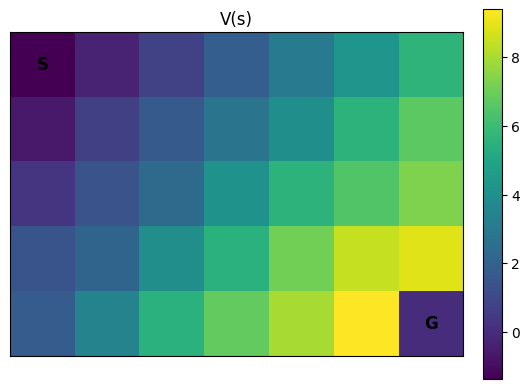

{'avg_return': -0.94, 'std_return': 1.9433, 'success_rate': 1.0, 'avg_steps': 11.94}


In [108]:
policy_plot_name = "policy_Q.png"
value_plot_name = "value_Q.png"
gif_name = "episode_Q.gif"
n_val_episodes = 50

env.reset()

pi = np.argmax(Q, axis = 1)
V = np.max(Q, axis = 1) # good-enough option for V* if Q is sufficiently converged(!)
# visualize policy and V(s)
plot_policy(env, pi, filename=policy_plot_name, title="Greedy Policy")
plot_value_heatmap(env, V, filename=value_plot_name, title="V(s)")
plt.close("all")

# evaluate deterministic policy over multiple episodes 
metrics = evaluate(env, policy=pi, n_episodes=n_val_episodes, seed=random_seed)
print(metrics)

# save one episode to gif
run_to_gif(env, policy=pi, gif_path=gif_name, fps=6)